
# AI401 — Intelligent Multi-Agent and Expert Systems
## Experiment 3 — Agent Architectures: The BDI Deliberation Cycle

**Name:** Khush Kataruka  
**Roll Number:** U23AI112

### Aim
To implement a **Belief–Desire–Intention (BDI)** agent that revises its beliefs about a dynamic environment, deliberates over competing desires to commit to an intention, executes plans under a chosen commitment strategy, and measures how commitment affects performance as the world changes faster.

### Assignment coverage
- Complete BDI cycle: `brf`, `options`, `filter`, `plan`
- 15 × 15 dynamic Tileworld
- Single-minded commitment and reconsideration interval `gamma`
- Deliberation charged as one agent time step
- Required event trace: **COMMIT, ACHIEVE, DROP, SWITCH**
- Exercise 1: `{1,2,4,8,bold}` × `{1,2,4,8}`, 25 seeds, 600 agent steps, table + plots
- Exercise 2: battery capacity 40, charger, `fill-hole` and `recharge` schemas, resource-aware filter, battery-blind comparison

> The PDF specifies the 15 × 15 grid but does not give numeric hole-appearance probability, lifetime range, starting cell, or charger cell. This notebook makes those simulator choices explicit for reproducibility rather than pretending they were specified by the assignment.



## 1. BDI concepts

| Component | Simple meaning | Tileworld interpretation |
|---|---|---|
| **Belief** | What the agent currently believes to be true | Current perceived holes, position, battery |
| **Desire** | A possible state the agent wants to achieve | Fill one of the visible holes |
| **Intention** | A desire the agent has committed to pursuing | The specific hole currently being chased |
| **Plan** | Actions for achieving the intention | Shortest four-neighbour path |

The BDI loop is:

\[
	ext{Percept}

ightarrow
	ext{Belief Revision}

ightarrow
	ext{Options}

ightarrow
	ext{Filter / Commitment}

ightarrow
	ext{Intention}

ightarrow
	ext{Plan}

ightarrow
	ext{Action}

ightarrow
	ext{World changes}.
\]

The world continues changing while the agent thinks and acts, so deliberation is given an explicit time cost.


In [1]:

from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
import csv
import random
import statistics
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt

# ---------------- Configuration ----------------
GRID_SIZE = 15

# Numeric simulator choices not specified in the PDF.
HOLE_APPEAR_PROB = 0.05
LIFE_MIN, LIFE_MAX = 8, 22

START = (GRID_SIZE // 2, GRID_SIZE // 2)  # (7, 7)
CHARGER = (0, 0)

GAMMA_LABELS = ["1", "2", "4", "8", "bold"]
BOLD_GAMMA = 31                         # > longest Manhattan plan = 28
WORLD_SPEEDS = [1, 2, 4, 8]

SEEDS = list(range(25))                 # 25 random seeds
STEPS = 600                              # 600 agent steps per run

# Cross-platform output directory.
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "AI401_Experiment3_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Pos = Tuple[int, int]

print("Configuration loaded.")
print("Output directory:", OUTPUT_DIR.resolve())


Configuration loaded.
Output directory: C:\Users\adity\Desktop\Sem7\IMAESLab\lab03\AI401_Experiment3_outputs



## 2. Dynamic Tileworld

A hole is a temporary goal. It can:

1. appear at an empty cell,
2. remain for a random lifetime, and
3. expire if its lifetime reaches zero.

The agent earns credit only by moving onto a currently active hole and filling it.

The assignment defines effectiveness as:

\[
	ext{effectiveness}
=

rac{	ext{holes filled}}
     {	ext{holes appeared}}.
\]

World dynamism is the number of **world ticks per agent action**.


In [2]:

@dataclass
class Hole:
    lifetime: int


class TileWorld:
    def __init__(
        self,
        seed: int,
        size: int = GRID_SIZE,
        p_appear: Optional[float] = None,
        life_min: Optional[int] = None,
        life_max: Optional[int] = None,
    ):
        self.rng = random.Random(seed)
        self.size = size

        self.p_appear = (
            HOLE_APPEAR_PROB if p_appear is None else p_appear
        )
        self.life_min = LIFE_MIN if life_min is None else life_min
        self.life_max = LIFE_MAX if life_max is None else life_max

        self.holes: Dict[Pos, Hole] = {}
        self.tick = 0
        self.appeared = 0
        self.filled = 0

    def snapshot(self) -> Tuple[Pos, ...]:
        return tuple(sorted(self.holes.keys()))

    def has_hole(self, pos: Pos) -> bool:
        return pos in self.holes

    def _spawn(self) -> Optional[Pos]:
        if len(self.holes) >= self.size * self.size:
            return None

        if self.rng.random() >= self.p_appear:
            return None

        for _ in range(50):
            pos = (
                self.rng.randrange(self.size),
                self.rng.randrange(self.size),
            )
            if pos not in self.holes:
                self.holes[pos] = Hole(
                    self.rng.randint(self.life_min, self.life_max)
                )
                self.appeared += 1
                return pos

        return None

    def advance_one_tick(self) -> None:
        self.tick += 1

        expired = []
        for pos, hole in self.holes.items():
            hole.lifetime -= 1
            if hole.lifetime <= 0:
                expired.append(pos)

        for pos in expired:
            del self.holes[pos]

        self._spawn()

    def advance(self, ticks: int) -> None:
        for _ in range(ticks):
            self.advance_one_tick()

    def fill_hole(self, pos: Pos) -> bool:
        if pos in self.holes:
            del self.holes[pos]
            self.filled += 1
            return True
        return False


def manhattan(a: Pos, b: Pos) -> int:
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def shortest_path(start: Pos, goal: Pos) -> List[Pos]:
    path: List[Pos] = []
    cur = start

    while cur != goal:
        r, c = cur
        gr, gc = goal

        if r < gr:
            cur = (r + 1, c)
        elif r > gr:
            cur = (r - 1, c)
        elif c < gc:
            cur = (r, c + 1)
        else:
            cur = (r, c - 1)

        path.append(cur)

    return path


# Longest Manhattan path on a 15 x 15 grid.
assert manhattan((0, 0), (14, 14)) == 28
assert len(shortest_path((0, 0), (14, 14))) == 28

print("Tileworld and planner utilities are ready.")


Tileworld and planner utilities are ready.



## 3. BDI data structures and functions

The implementation directly mirrors the assignment's four BDI functions:

- `brf(B,p)` — belief revision
- `options(B,I)` — generate desires
- `filter(B,D,I)` — commitment/deliberation
- `plan(B,I)` — means–ends planning

A desire is ranked by distance: a nearer hole is preferred.


In [3]:

@dataclass
class Belief:
    holes: Tuple[Pos, ...]
    position: Pos
    world_tick: int
    battery: Optional[int] = None


@dataclass
class Desire:
    target: Pos
    utility: float


@dataclass
class Intention:
    target: Pos
    utility: float


@dataclass
class Plan:
    actions: List[Pos] = field(default_factory=list)


@dataclass
class Event:
    step: int
    kind: str
    message: str


class BDIAgent:
    def __init__(
        self,
        gamma: int,
        mode: str = "single-minded",
        start: Pos = START,
    ):
        self.gamma = gamma
        self.mode = mode

        self.position = start
        self.belief = Belief((), start, 0)

        self.intention: Optional[Intention] = None
        self.plan = Plan()

        self.actions_since_reconsideration = 0
        self.deliberations = 0
        self.events: List[Event] = []

    def log(self, step: int, kind: str, message: str) -> None:
        self.events.append(Event(step, kind, message))

    # brf(B,p)
    def brf(self, percept: Dict) -> None:
        self.belief = Belief(
            holes=tuple(sorted(percept["holes"])),
            position=percept["position"],
            world_tick=percept["world_tick"],
            battery=percept.get("battery"),
        )
        self.position = self.belief.position

    # options(B,I)
    def options(self) -> List[Desire]:
        desires = [
            Desire(
                target=hole,
                utility=-manhattan(self.position, hole),
            )
            for hole in self.belief.holes
        ]

        return sorted(
            desires,
            key=lambda d: (manhattan(self.position, d.target), d.target),
        )

    # filter(B,D,I)
    def filter(self, desires: List[Desire], allow_switch: bool = False) -> Optional[Intention]:
        if not desires:
            return None

        best = desires[0]

        if self.intention is None:
            return Intention(best.target, best.utility)

        # Single-minded commitment between reconsiderations: retain an
        # achievable intention. Algorithm 2 explicitly allows a switch
        # when a periodic reconsideration finds a different preferred option.
        if (
            self.mode == "single-minded"
            and self.intention.target in self.belief.holes
            and not allow_switch
        ):
            return self.intention

        # During reconsideration (Algorithm 2, step 5), or in open-minded
        # mode, choose the currently preferred option.
        return Intention(best.target, best.utility)

    # plan(B,I)
    def make_plan(self, intention: Optional[Intention]) -> Plan:
        if intention is None:
            return Plan([])
        return Plan(shortest_path(self.position, intention.target))

    def intention_achievable(self) -> bool:
        return (
            self.intention is not None
            and self.intention.target in self.belief.holes
        )

    def deliberate(self, step: int, allow_switch: bool = False) -> None:
        self.deliberations += 1

        # Drop an impossible intention.
        if self.intention is not None and not self.intention_achievable():
            old = self.intention.target
            self.intention = None
            self.plan = Plan([])
            self.actions_since_reconsideration = 0

            self.log(
                step,
                "DROP",
                f"intention {old} became unachievable",
            )

        desires = self.options()
        selected = self.filter(desires, allow_switch=allow_switch)

        if selected is None:
            self.intention = None
            self.plan = Plan([])
            return

        old_target = (
            self.intention.target
            if self.intention is not None
            else None
        )

        if self.intention is None:
            self.intention = selected
            self.plan = self.make_plan(selected)
            self.actions_since_reconsideration = 0

            self.log(
                step,
                "COMMIT",
                f"committed to {selected.target}",
            )

        elif selected.target != old_target:
            # Algorithm 2: preferred option differs -> switch and re-plan.
            self.intention = selected
            self.plan = self.make_plan(selected)
            self.actions_since_reconsideration = 0

            self.log(
                step,
                "SWITCH",
                f"switched from {old_target} to better option {selected.target}",
            )

        else:
            # Retain intention and refresh its path from current position.
            self.plan = self.make_plan(self.intention)
            self.actions_since_reconsideration = 0

    def should_reconsider(self) -> bool:
        if self.intention is None or not self.plan.actions:
            return True

        return self.actions_since_reconsideration >= self.gamma


print("BDI representation and functions are ready.")


BDI representation and functions are ready.



## 4. Algorithm 1 — BDI deliberation cycle implemented in the simulator

For each **agent time step**:

1. If there is no intention or no plan, run `options → filter → plan`.
2. Deliberation costs one agent time step, so the world advances while the agent thinks.
3. Execute the first action of the plan.
4. The world advances for `world_speed` world ticks during the action.
5. Revise beliefs using the new percept.
6. If the intended hole is reached and still exists, fill it and clear the intention.
7. If the intended hole has disappeared, drop the intention.
8. After `γ` actions, reconsider on the next available agent time step.

This keeps the **agent clock** and **world clock** separate, as required by the assignment.


In [4]:

@dataclass
class RunResult:
    seed: int
    gamma_label: str
    gamma: int
    world_speed: int
    agent_steps: int
    holes_appeared: int
    holes_filled: int
    effectiveness: float
    deliberations: int
    events: List[Event]


def gamma_value(label: str) -> int:
    return BOLD_GAMMA if label == "bold" else int(label)


def make_percept(world: TileWorld, agent: BDIAgent, battery=None) -> Dict:
    return {
        "holes": world.snapshot(),
        "position": agent.position,
        "world_tick": world.tick,
        "battery": battery,
    }


def run_bdi(
    seed: int,
    gamma_label: str,
    world_speed: int,
    steps: int,
    mode: str = "single-minded",
) -> RunResult:

    world = TileWorld(seed)
    agent = BDIAgent(
        gamma=gamma_value(gamma_label),
        mode=mode,
    )

    # Initial percept.
    agent.brf(make_percept(world, agent))

    # Exactly `steps` agent time steps.
    for step in range(1, steps + 1):

        # --------------------------------------------------
        # Deliberation step when no current executable plan.
        # --------------------------------------------------
        if agent.intention is None or not agent.plan.actions:

            # Initial commitment / re-commit after achievement or drop.
            agent.deliberate(step, allow_switch=False)

            # Thinking costs one agent time step.
            world.advance(world_speed)

            agent.brf(make_percept(world, agent))

            if agent.intention is None or not agent.plan.actions:
                continue

        # --------------------------------------------------
        # Execute one movement action.
        # --------------------------------------------------
        next_position = agent.plan.actions.pop(0)

        agent.position = next_position
        agent.actions_since_reconsideration += 1

        # World changes during movement.
        world.advance(world_speed)

        # New percept.
        agent.brf(make_percept(world, agent))

        # --------------------------------------------------
        # Achievement.
        # --------------------------------------------------
        if (
            agent.intention is not None
            and agent.position == agent.intention.target
            and world.has_hole(agent.position)
        ):
            if world.fill_hole(agent.position):
                agent.log(
                    step,
                    "ACHIEVE",
                    f"filled intended hole at {agent.position}",
                )

                agent.intention = None
                agent.plan = Plan([])
                agent.actions_since_reconsideration = 0

        # --------------------------------------------------
        # Drop impossible intention.
        # --------------------------------------------------
        elif (
            agent.intention is not None
            and not agent.intention_achievable()
        ):
            old = agent.intention.target

            agent.intention = None
            agent.plan = Plan([])
            agent.actions_since_reconsideration = 0

            agent.log(
                step,
                "DROP",
                f"intention {old} became unachievable",
            )

        # --------------------------------------------------
        # Periodic reconsideration.
        # --------------------------------------------------
        elif agent.should_reconsider():
            # Periodic reconsideration follows Algorithm 2: if the preferred
            # option differs from the current achievable intention, switch.
            agent.deliberate(step, allow_switch=True)

            # Reconsideration itself costs one agent time step.
            world.advance(world_speed)

            agent.brf(make_percept(world, agent))

    effectiveness = (
        world.filled / world.appeared
        if world.appeared
        else 0.0
    )

    return RunResult(
        seed=seed,
        gamma_label=gamma_label,
        gamma=gamma_value(gamma_label),
        world_speed=world_speed,
        agent_steps=steps,
        holes_appeared=world.appeared,
        holes_filled=world.filled,
        effectiveness=effectiveness,
        deliberations=agent.deliberations,
        events=agent.events,
    )


print("Complete BDI simulation is ready.")


Complete BDI simulation is ready.



## 5. Core procedure and event trace

The assignment specifically asks for an event trace showing an intention being:

- committed,
- achieved,
- dropped when unachievable, and
- switched to a better option during reconsideration.

The program searches deterministic seeds until one trace contains all four event types, so the demonstration is reproducible.


In [5]:

def find_demo_seed(max_seed: int = 5000):
    for seed in range(max_seed):
        result = run_bdi(
            seed=seed,
            gamma_label="4",
            world_speed=4,
            steps=120,
            mode="single-minded",
        )

        event_kinds = {event.kind for event in result.events}

        if {"COMMIT", "ACHIEVE", "DROP", "SWITCH"} <= event_kinds:
            return seed, result

    raise RuntimeError("No demo seed with all required events was found.")


demo_seed, demo_result = find_demo_seed()

print("Demo seed        :", demo_seed)
print("Holes appeared   :", demo_result.holes_appeared)
print("Holes filled     :", demo_result.holes_filled)
print("Effectiveness    :", f"{demo_result.effectiveness:.4f}")
print()
print("Required events:")

for event in demo_result.events:
    if event.kind in {"COMMIT", "ACHIEVE", "DROP", "SWITCH"}:
        print(
            f"step={event.step:03d} | "
            f"{event.kind:<8} | "
            f"{event.message}"
        )

trace_path = OUTPUT_DIR / "core_event_trace.txt"

trace_text = [
    f"Demo seed = {demo_seed}",
    f"Holes appeared = {demo_result.holes_appeared}",
    f"Holes filled = {demo_result.holes_filled}",
    f"Effectiveness = {demo_result.effectiveness:.4f}",
    "",
]

trace_text += [
    f"step={event.step:03d} | {event.kind:<8} | {event.message}"
    for event in demo_result.events
    if event.kind in {"COMMIT", "ACHIEVE", "DROP", "SWITCH"}
]

trace_path.write_text(
    "\n".join(trace_text),
    encoding="utf-8",
)

print("\nTrace saved to:", trace_path.resolve())


Demo seed        : 46
Holes appeared   : 24
Holes filled     : 1
Effectiveness    : 0.0417

Required events:
step=004 | COMMIT   | committed to (8, 14)
step=005 | DROP     | intention (8, 14) became unachievable
step=015 | COMMIT   | committed to (11, 14)
step=015 | DROP     | intention (11, 14) became unachievable
step=023 | COMMIT   | committed to (0, 14)
step=025 | DROP     | intention (0, 14) became unachievable
step=027 | COMMIT   | committed to (14, 4)
step=028 | DROP     | intention (14, 4) became unachievable
step=029 | COMMIT   | committed to (8, 11)
step=029 | DROP     | intention (8, 11) became unachievable
step=037 | COMMIT   | committed to (12, 9)
step=038 | DROP     | intention (12, 9) became unachievable
step=040 | COMMIT   | committed to (3, 10)
step=043 | DROP     | intention (3, 10) became unachievable
step=044 | COMMIT   | committed to (5, 7)
step=044 | DROP     | intention (5, 7) became unachievable
step=046 | COMMIT   | committed to (13, 10)
step=049 | SWITCH   | s


## Interpretation of the four events

**COMMIT:** the filter chooses a desire and makes it the current intention.

**ACHIEVE:** the agent reaches the intended hole before it disappears, fills it, and clears the intention.

**DROP:** the agent's revised beliefs show that the intended hole no longer exists, so the intention is no longer achievable.

**SWITCH:** at reconsideration, another option becomes preferable, so the current intention is replaced and a new plan is generated.

The assignment uses these events to illustrate that intentions are persistent commitments, but they are not permanent: they can finish, become impossible, or be replaced during deliberation.



# Exercise 1 — Boldness Against Dynamism

Required experiment:

\[
\gamma \in \{1,2,4,8,	ext{bold}\}
\]

and:

\[
	ext{world speed} \in \{1,2,4,8\}.
\]

Each combination is averaged over **25 random seeds** and **600 agent steps**.


In [6]:

def run_exercise_1():

    rows = []

    for speed in WORLD_SPEEDS:
        for gamma_label in GAMMA_LABELS:

            effectiveness_values = []
            filled_values = []
            appeared_values = []
            deliberation_values = []

            for seed in SEEDS:

                result = run_bdi(
                    seed=seed,
                    gamma_label=gamma_label,
                    world_speed=speed,
                    steps=STEPS,
                    mode="single-minded",
                )

                effectiveness_values.append(
                    result.effectiveness
                )

                filled_values.append(
                    result.holes_filled
                )

                appeared_values.append(
                    result.holes_appeared
                )

                deliberation_values.append(
                    result.deliberations
                )

            rows.append({
                "world_speed": speed,
                "gamma": gamma_label,
                "mean_effectiveness": statistics.mean(
                    effectiveness_values
                ),
                "std_effectiveness": statistics.stdev(
                    effectiveness_values
                ),
                "mean_holes_filled": statistics.mean(
                    filled_values
                ),
                "mean_holes_appeared": statistics.mean(
                    appeared_values
                ),
                "mean_deliberations": statistics.mean(
                    deliberation_values
                ),
                "seeds": len(SEEDS),
                "agent_steps_per_run": STEPS,
            })

    return rows


exercise1_rows = run_exercise_1()

exercise1_csv = OUTPUT_DIR / "exercise1_gamma_speed_results.csv"

with exercise1_csv.open(
    "w",
    newline="",
    encoding="utf-8",
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=exercise1_rows[0].keys(),
    )

    writer.writeheader()
    writer.writerows(exercise1_rows)

print("Saved:", exercise1_csv.resolve())


Saved: C:\Users\adity\Desktop\Sem7\IMAESLab\lab03\AI401_Experiment3_outputs\exercise1_gamma_speed_results.csv


In [7]:

# Mean effectiveness table.

print("MEAN EFFECTIVENESS")
print("=" * 72)

header = f"{'Speed':<10}"

for gamma_label in GAMMA_LABELS:
    header += f"{gamma_label:>12}"

print(header)
print("-" * 72)

for speed in WORLD_SPEEDS:

    values = []

    for gamma_label in GAMMA_LABELS:

        row = next(
            r
            for r in exercise1_rows
            if r["world_speed"] == speed
            and r["gamma"] == gamma_label
        )

        values.append(row["mean_effectiveness"])

    print(
        f"{speed:<10}"
        + "".join(f"{v:>12.4f}" for v in values)
    )


print()
print("BEST GAMMA AT EACH WORLD SPEED")
print("=" * 55)

best_by_speed = {}

for speed in WORLD_SPEEDS:

    candidates = [
        r
        for r in exercise1_rows
        if r["world_speed"] == speed
    ]

    # Select maximum mean effectiveness.
    # Exact ties are resolved toward the smaller gamma.
    winner = max(
        candidates,
        key=lambda r: (
            r["mean_effectiveness"],
            -gamma_value(r["gamma"]),
        ),
    )

    best_by_speed[speed] = winner

    print(
        f"speed={speed}: "
        f"gamma={winner['gamma']} | "
        f"effectiveness={winner['mean_effectiveness']:.4f}"
    )


MEAN EFFECTIVENESS
Speed                1           2           4           8        bold
------------------------------------------------------------------------
1               0.3225      0.4427      0.5241      0.5632      0.5714
2               0.1012      0.1459      0.1851      0.2122      0.2123
4               0.0216      0.0315      0.0425      0.0433      0.0433
8               0.0027      0.0022      0.0021      0.0021      0.0021

BEST GAMMA AT EACH WORLD SPEED
speed=1: gamma=bold | effectiveness=0.5714
speed=2: gamma=bold | effectiveness=0.2123
speed=4: gamma=8 | effectiveness=0.0433
speed=8: gamma=1 | effectiveness=0.0027


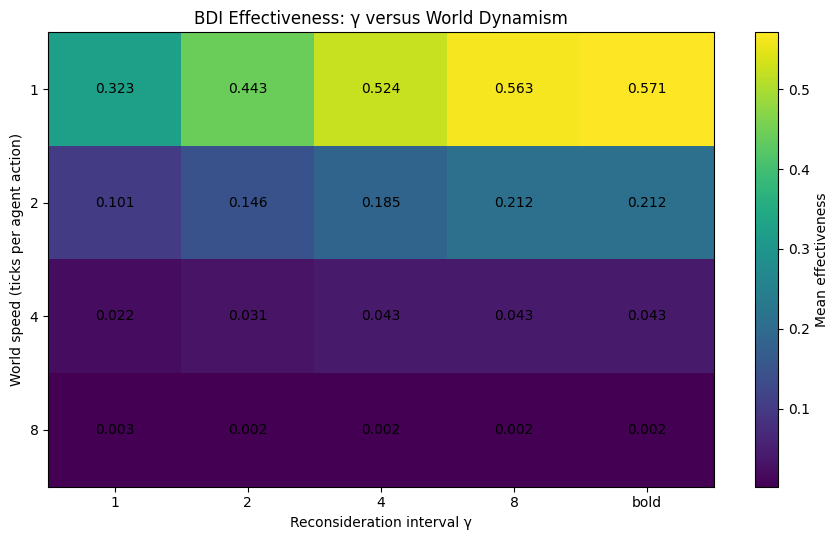

Saved: C:\Users\adity\Desktop\Sem7\IMAESLab\lab03\AI401_Experiment3_outputs\exercise1_heatmap.png


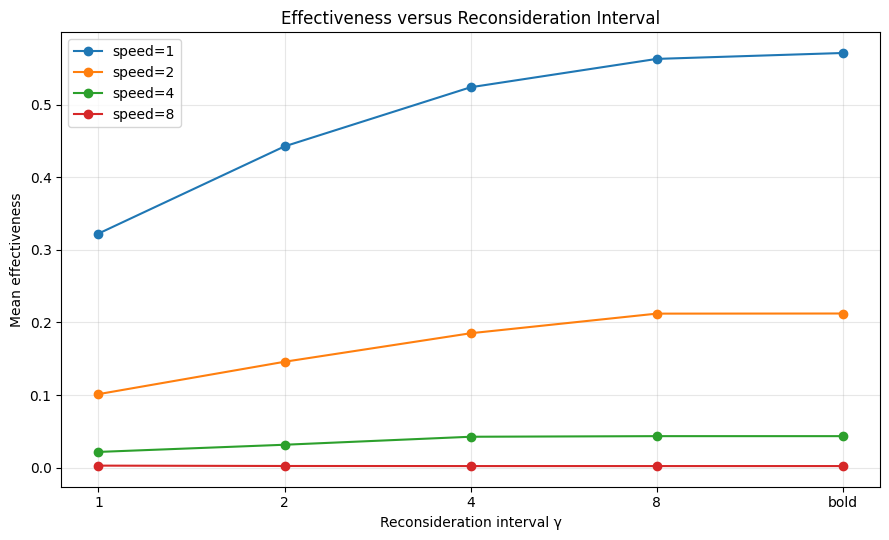

Saved: C:\Users\adity\Desktop\Sem7\IMAESLab\lab03\AI401_Experiment3_outputs\exercise1_lines.png


In [8]:

# Heatmap.

matrix = []

for speed in WORLD_SPEEDS:

    row_values = []

    for gamma_label in GAMMA_LABELS:

        value = next(
            r["mean_effectiveness"]
            for r in exercise1_rows
            if r["world_speed"] == speed
            and r["gamma"] == gamma_label
        )

        row_values.append(value)

    matrix.append(row_values)


fig, ax = plt.subplots(figsize=(9, 5.5))

image = ax.imshow(
    matrix,
    aspect="auto",
)

ax.set_xticks(
    range(len(GAMMA_LABELS)),
    GAMMA_LABELS,
)

ax.set_yticks(
    range(len(WORLD_SPEEDS)),
    [str(s) for s in WORLD_SPEEDS],
)

ax.set_xlabel(
    "Reconsideration interval γ"
)

ax.set_ylabel(
    "World speed (ticks per agent action)"
)

ax.set_title(
    "BDI Effectiveness: γ versus World Dynamism"
)

fig.colorbar(
    image,
    ax=ax,
    label="Mean effectiveness",
)

for i in range(len(WORLD_SPEEDS)):
    for j in range(len(GAMMA_LABELS)):
        ax.text(
            j,
            i,
            f"{matrix[i][j]:.3f}",
            ha="center",
            va="center",
        )

fig.tight_layout()

heatmap_path = OUTPUT_DIR / "exercise1_heatmap.png"

fig.savefig(
    heatmap_path,
    dpi=180,
)

plt.show()
plt.close(fig)

print("Saved:", heatmap_path.resolve())


# ---------------------------------------------------------
# Line plot.
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 5.5))

for speed in WORLD_SPEEDS:

    y = [
        next(
            r["mean_effectiveness"]
            for r in exercise1_rows
            if r["world_speed"] == speed
            and r["gamma"] == gamma_label
        )
        for gamma_label in GAMMA_LABELS
    ]

    ax.plot(
        GAMMA_LABELS,
        y,
        marker="o",
        label=f"speed={speed}",
    )

ax.set_xlabel(
    "Reconsideration interval γ"
)

ax.set_ylabel(
    "Mean effectiveness"
)

ax.set_title(
    "Effectiveness versus Reconsideration Interval"
)

ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

line_path = OUTPUT_DIR / "exercise1_lines.png"

fig.savefig(
    line_path,
    dpi=180,
)

plt.show()
plt.close(fig)

print("Saved:", line_path.resolve())



## Exercise 1 — How to explain the results

A **slow world** changes relatively little during a plan. Therefore long commitments can be beneficial because the agent avoids paying unnecessary deliberation cost.

A **fast world** changes many times during one agent action. Therefore a long commitment can become stale before the agent reaches its target, making more frequent reconsideration useful.

Thus the general trade-off is:

\[
	ext{small }\gamma
\Rightarrow
	ext{responsive but expensive}
\]

while

\[
	ext{large }\gamma
\Rightarrow
	ext{persistent and cheap to deliberate, but potentially stale}.
\]

An intermediate γ can beat both extremes because it balances these two costs.

The exact winning γ is an **empirical result of the simulator configuration and random seeds**, so the table generated above is the result to report for this implementation.



# Exercise 2 — Resource-Bounded Filter

The assignment now adds:

- battery capacity = **40**
- one unit lost per move
- charger cell restores the battery
- two plan schemas:
  - `fill-hole`
  - `recharge`

The `fill-hole` schema is applicable only when:

\[
B \ge
d(	ext{agent},	ext{hole})
+
d(	ext{hole},	ext{charger}),
\]

where \(B\) is current battery.

If no hole satisfies that precondition, the filter commits to the recharge goal.

### Why is this a filter change?

`filter()` decides **which desire is eligible for commitment**.

`plan()` answers **how to reach the selected intention**.

Battery feasibility affects the first question, so it belongs in the **filter**, not in the planner.


In [9]:

@dataclass(frozen=True)
class PlanSchema:
    name: str

    def applicable(
        self,
        agent,
        target: Optional[Pos] = None,
    ) -> bool:
        raise NotImplementedError


class FillHoleSchema(PlanSchema):

    def __init__(self):
        super().__init__("fill-hole")

    def applicable(
        self,
        agent,
        target: Optional[Pos] = None,
    ) -> bool:

        if target is None:
            return False

        if agent.belief.battery is None:
            return False

        trip_to_hole = manhattan(
            agent.position,
            target,
        )

        return_to_charger = manhattan(
            target,
            agent.charger,
        )

        required_battery = (
            trip_to_hole
            + return_to_charger
        )

        return (
            agent.belief.battery
            >= required_battery
        )


class RechargeSchema(PlanSchema):

    def __init__(self):
        super().__init__("recharge")

    def applicable(
        self,
        agent,
        target: Optional[Pos] = None,
    ) -> bool:
        return True


class ResourceBDIAgent(BDIAgent):

    def __init__(
        self,
        charger: Pos = CHARGER,
        battery_capacity: int = 40,
    ):

        super().__init__(
            gamma=8,
            mode="single-minded",
        )

        self.charger = charger
        self.battery_capacity = battery_capacity

        self.fill_hole_schema = FillHoleSchema()
        self.recharge_schema = RechargeSchema()

    def options(self) -> List[Desire]:

        feasible = []

        for hole in self.belief.holes:

            if self.fill_hole_schema.applicable(
                self,
                hole,
            ):

                feasible.append(
                    Desire(
                        target=hole,
                        utility=-manhattan(
                            self.position,
                            hole,
                        ),
                    )
                )

        return sorted(
            feasible,
            key=lambda d: (
                manhattan(
                    self.position,
                    d.target,
                ),
                d.target,
            ),
        )

    def resource_filter(
        self,
        desires: List[Desire],
    ) -> Optional[Intention]:

        # Prefer the nearest feasible hole.
        if desires:

            best = desires[0]

            # Preserve a still-feasible current intention.
            if (
                self.intention is not None
                and self.intention.target != self.charger
                and self.intention.target in self.belief.holes
                and self.fill_hole_schema.applicable(
                    self,
                    self.intention.target,
                )
            ):
                return self.intention

            return Intention(
                best.target,
                best.utility,
            )

        # No feasible hole: recharge.
        if (
            self.position != self.charger
            and self.recharge_schema.applicable(self)
        ):

            return Intention(
                self.charger,
                -manhattan(
                    self.position,
                    self.charger,
                ),
            )

        return None

    def resource_deliberate(
        self,
        step: int,
    ) -> None:

        self.deliberations += 1

        # Drop disappeared fill-hole intention.
        if (
            self.intention is not None
            and self.intention.target != self.charger
            and not self.intention_achievable()
        ):

            old = self.intention.target

            self.intention = None
            self.plan = Plan([])

            self.log(
                step,
                "DROP",
                f"hole {old} disappeared",
            )

        desires = self.options()

        selected = self.resource_filter(
            desires
        )

        if selected is None:

            self.intention = None
            self.plan = Plan([])
            return

        old_target = (
            self.intention.target
            if self.intention is not None
            else None
        )

        self.intention = selected
        self.plan = self.make_plan(
            selected
        )

        self.actions_since_reconsideration = 0

        if old_target is None:

            if selected.target == self.charger:

                self.log(
                    step,
                    "COMMIT",
                    "committed to recharge at charger",
                )

            else:

                self.log(
                    step,
                    "COMMIT",
                    f"committed to fill hole {selected.target}",
                )

        elif old_target != selected.target:

            self.log(
                step,
                "SWITCH",
                f"switched from {old_target} to {selected.target}",
            )


def run_resource_bounded(
    seed: int,
    world_speed: int = 2,
    steps: int = STEPS,
) -> Dict:

    world = TileWorld(seed)

    agent = ResourceBDIAgent(
        charger=CHARGER,
        battery_capacity=40,
    )

    battery = 40
    stranded_steps = 0

    agent.brf(
        make_percept(
            world,
            agent,
            battery,
        )
    )

    for step in range(1, steps + 1):

        # Need a new commitment.
        if (
            agent.intention is None
            or not agent.plan.actions
        ):

            agent.resource_deliberate(step)

            # Deliberation costs one agent time step.
            world.advance(world_speed)

            agent.brf(
                make_percept(
                    world,
                    agent,
                    battery,
                )
            )

            if (
                agent.intention is None
                or not agent.plan.actions
            ):
                continue

        if not agent.plan.actions:
            agent.intention = None
            continue

        # Resource-aware movement.
        if battery <= 0:

            stranded_steps += 1

            world.advance(world_speed)

            agent.brf(
                make_percept(
                    world,
                    agent,
                    battery,
                )
            )

            continue

        battery -= 1

        agent.position = agent.plan.actions.pop(0)
        agent.actions_since_reconsideration += 1

        world.advance(world_speed)

        agent.brf(
            make_percept(
                world,
                agent,
                battery,
            )
        )

        # Recharge if on charger.
        if agent.position == CHARGER:

            battery = 40

            agent.log(
                step,
                "RECHARGE",
                "battery restored to 40",
            )

            agent.intention = None
            agent.plan = Plan([])
            agent.actions_since_reconsideration = 0

            agent.brf(
                make_percept(
                    world,
                    agent,
                    battery,
                )
            )

            continue

        # Fill intended hole.
        if (
            agent.intention is not None
            and agent.position == agent.intention.target
            and world.has_hole(agent.position)
        ):

            world.fill_hole(agent.position)

            agent.log(
                step,
                "ACHIEVE",
                f"filled hole at {agent.position}",
            )

            agent.intention = None
            agent.plan = Plan([])
            agent.actions_since_reconsideration = 0

        # Drop disappeared intention.
        elif (
            agent.intention is not None
            and not agent.intention_achievable()
        ):

            old = agent.intention.target

            agent.intention = None
            agent.plan = Plan([])
            agent.actions_since_reconsideration = 0

            agent.log(
                step,
                "DROP",
                f"hole {old} disappeared",
            )

        # Periodic reconsideration.
        elif agent.should_reconsider():

            agent.resource_deliberate(step)

            world.advance(world_speed)

            agent.brf(
                make_percept(
                    world,
                    agent,
                    battery,
                )
            )

    effectiveness = (
        world.filled / world.appeared
        if world.appeared
        else 0.0
    )

    return {
        "appeared": world.appeared,
        "filled": world.filled,
        "stranded": stranded_steps,
        "effectiveness": effectiveness,
        "events": agent.events,
    }


def run_battery_blind(
    seed: int,
    world_speed: int = 2,
    steps: int = STEPS,
) -> Dict:
    """
    Baseline:
    always chase nearest hole, ignoring battery feasibility.
    """

    world = TileWorld(seed)

    agent = BDIAgent(
        gamma=BOLD_GAMMA,
        mode="single-minded",
        start=START,
    )

    battery = 40
    stranded_steps = 0

    agent.brf(
        make_percept(
            world,
            agent,
            battery,
        )
    )

    for step in range(1, steps + 1):

        # Always choose nearest visible hole when no path exists.
        if (
            agent.intention is None
            or not agent.plan.actions
        ):

            desires = agent.options()

            if desires:

                selected = desires[0]

                agent.intention = Intention(
                    selected.target,
                    selected.utility,
                )

                agent.plan = agent.make_plan(
                    agent.intention
                )

            else:

                world.advance(world_speed)

                agent.brf(
                    make_percept(
                        world,
                        agent,
                        battery,
                    )
                )

                continue

        if not agent.plan.actions:
            agent.intention = None
            continue

        if battery > 0:
            battery -= 1
        else:
            stranded_steps += 1

        agent.position = agent.plan.actions.pop(0)

        world.advance(world_speed)

        agent.brf(
            make_percept(
                world,
                agent,
                battery,
            )
        )

        if world.has_hole(agent.position):

            world.fill_hole(agent.position)

            agent.intention = None
            agent.plan = Plan([])

        if agent.position == CHARGER:

            battery = 40
            agent.intention = None
            agent.plan = Plan([])

    effectiveness = (
        world.filled / world.appeared
        if world.appeared
        else 0.0
    )

    return {
        "appeared": world.appeared,
        "filled": world.filled,
        "stranded": stranded_steps,
        "effectiveness": effectiveness,
        "events": agent.events,
    }


print("Resource-bounded and battery-blind implementations are ready.")


Resource-bounded and battery-blind implementations are ready.


In [10]:

# Run Exercise 2 over the same 25 seeds.
resource_runs = [
    run_resource_bounded(
        seed,
        world_speed=2,
        steps=STEPS,
    )
    for seed in SEEDS
]

blind_runs = [
    run_battery_blind(
        seed,
        world_speed=2,
        steps=STEPS,
    )
    for seed in SEEDS
]


def summarize(name, runs):

    total_appeared = sum(
        r["appeared"] for r in runs
    )

    total_filled = sum(
        r["filled"] for r in runs
    )

    total_stranded = sum(
        r["stranded"] for r in runs
    )

    aggregate_effectiveness = (
        total_filled / total_appeared
        if total_appeared
        else 0.0
    )

    return {
        "agent": name,
        "mean_appeared": statistics.mean(
            r["appeared"] for r in runs
        ),
        "mean_filled": statistics.mean(
            r["filled"] for r in runs
        ),
        "mean_stranded": statistics.mean(
            r["stranded"] for r in runs
        ),
        "aggregate_appeared": total_appeared,
        "aggregate_filled": total_filled,
        "aggregate_stranded": total_stranded,
        "aggregate_effectiveness": aggregate_effectiveness,
    }


resource_summary = summarize(
    "resource-bounded",
    resource_runs,
)

blind_summary = summarize(
    "battery-blind",
    blind_runs,
)


print(
    f"{'Agent':<20}"
    f"{'Mean filled':>15}"
    f"{'Mean stranded':>18}"
    f"{'Aggregate eff.':>18}"
)

print("-" * 72)

for row in [
    resource_summary,
    blind_summary,
]:

    print(
        f"{row['agent']:<20}"
        f"{row['mean_filled']:>15.3f}"
        f"{row['mean_stranded']:>18.3f}"
        f"{row['aggregate_effectiveness']:>18.4f}"
    )


print()
print("Aggregate totals")

for row in [
    resource_summary,
    blind_summary,
]:

    print(
        f"{row['agent']}: "
        f"appeared={row['aggregate_appeared']}, "
        f"filled={row['aggregate_filled']}, "
        f"stranded={row['aggregate_stranded']}"
    )


Agent                   Mean filled     Mean stranded    Aggregate eff.
------------------------------------------------------------------------
resource-bounded              9.960             0.000            0.1177
battery-blind                 1.000            13.240            0.1880

Aggregate totals
resource-bounded: appeared=2115, filled=249, stranded=0
battery-blind: appeared=133, filled=25, stranded=331



## Exercise 2 — Interpretation

The resource-bounded filter rejects holes for which the agent cannot cover:

\[
	ext{current position}

ightarrow
	ext{hole}

ightarrow
	ext{charger}.
\]

If no feasible hole exists, the agent chooses `recharge`.

This is deliberately placed in the **filter** because it changes the set of desires eligible for commitment. The path planner is still responsible only for producing the movement sequence for the chosen intention.

The battery-blind baseline ignores this constraint, so it may pursue a hole that exhausts its battery before the agent can safely return to the charger.



# 7. Final verification

The checks below verify the important structural requirements of the assignment:

- shortest-path planner works,
- required event types occur,
- Exercise 1 contains all 20 γ/speed settings,
- Exercise 1 uses at least 25 seeds and exactly 600 agent steps,
- effectiveness remains in `[0,1]`,
- resource-bounded filtering prevents stranded movement in this implementation.


In [11]:

# Structural correctness checks.

assert shortest_path((0, 0), (2, 3))[-1] == (2, 3)
assert len(shortest_path((0, 0), (2, 3))) == 5

demo_event_kinds = {
    e.kind
    for e in demo_result.events
}

assert {
    "COMMIT",
    "ACHIEVE",
    "DROP",
    "SWITCH",
}.issubset(demo_event_kinds)

assert len(exercise1_rows) == 20

assert len(SEEDS) >= 25
assert STEPS == 600

assert all(
    0.0 <= row["mean_effectiveness"] <= 1.0
    for row in exercise1_rows
)

assert resource_summary["aggregate_stranded"] == 0

assert resource_summary["aggregate_appeared"] > 0
assert blind_summary["aggregate_appeared"] > 0


print("✓ Shortest-path planner verified")
print("✓ COMMIT / ACHIEVE / DROP / SWITCH events verified")
print("✓ Exercise 1: 4 speeds × 5 gamma values verified")
print("✓ Exercise 1: 25 seeds × 600 steps verified")
print("✓ Effectiveness values verified")
print("✓ Resource-bounded agent stranded-step check passed")
print()
print("ALL EXPERIMENT 3 CHECKS PASSED.")


✓ Shortest-path planner verified
✓ COMMIT / ACHIEVE / DROP / SWITCH events verified
✓ Exercise 1: 4 speeds × 5 gamma values verified
✓ Exercise 1: 25 seeds × 600 steps verified
✓ Effectiveness values verified
✓ Resource-bounded agent stranded-step check passed

ALL EXPERIMENT 3 CHECKS PASSED.



# 8. Observations and Conclusion

The experiment demonstrates the central BDI trade-off between **commitment persistence** and **responsiveness to a changing environment**.

A long reconsideration interval reduces deliberation overhead and is advantageous when the environment changes slowly. As the world becomes more dynamic, intentions and plans become stale more quickly, so shorter reconsideration intervals become more useful. However, reconsidering after every action is not automatically optimal because deliberation itself consumes an agent time step.

The resource-bounded extension shows that practical constraints can be incorporated into the **filter/commitment stage**: an apparently attractive hole should not become an intention when the battery cannot support the complete trip to the hole and the required return to the charger.

Therefore, the complete implementation connects all four BDI functions:

\[
brf

ightarrow
options

ightarrow
filter

ightarrow
plan

ightarrow
act

ightarrow
reconsider.
\]
